# PROJECT-1 #

## Sales Analysis Project ##

## Objective of Project ##

### Analyze overall sales and performance ###
### Identify high performing regions and categories ###
### Study session and yearly trends ###
### Evaluate discount impace on sales ###
### Understand customer and payment behaviour ###

### Dataset Overview ###

#### This dataset used in project is sourced from kaggle. The URL is #### 
###### https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data ######

### Libraries used ###

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset ###

In [5]:
df = pd.read_csv("Amazon Sale Report.csv")

C:\Users\aryas\AppData\Local\Temp\ipykernel_15372\652367067.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv")


### Basic Exploration ###

In [6]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [7]:
df.tail()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
128970,128970,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,...,INR,517.0,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN,False
128971,128971,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,...,INR,999.0,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128972,128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,...,INR,690.0,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN,False
128973,128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,...,INR,1199.0,Halol,Gujarat,389350.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128974,128974,408-7436540-8728312,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0003,J0003-SET-S,Set,...,INR,696.0,Raipur,CHHATTISGARH,492014.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [8]:
df.dtypes

index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids          object
B2B                      bool
fulfilled-by           object
Unnamed: 22            object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [10]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [11]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

### Total Sum ###

In [13]:
total_sales = df["Amount"].sum()
print(total_sales)

78592678.29999998


### Monthly Sales Trend ###

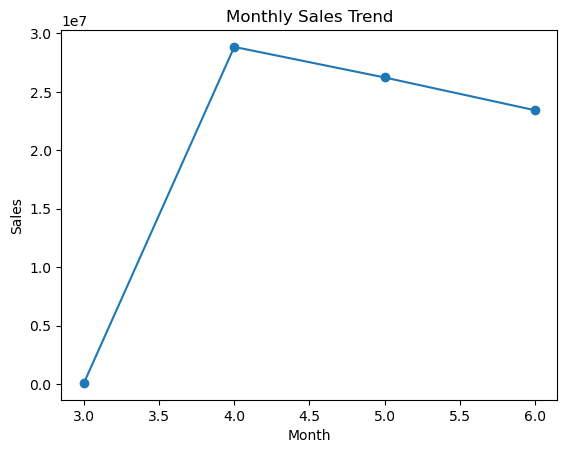

In [17]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["Amount"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

### Top Categories ###

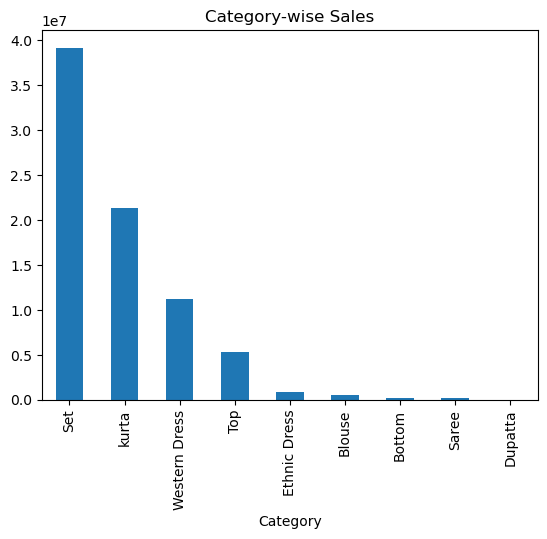

In [18]:
top_category = df.groupby("Category")["Amount"].sum().sort_values(ascending = False)
top_category.plot(kind="bar")
plt.title("Category-wise Sales")
plt.show()

### Top Selling Products ###

In [19]:
top_selling = df.groupby("SKU")["Qty"].sum().sort_values(ascending=False).head(10)
print(top_selling)

SKU
JNE3797-KR-L       661
JNE3797-KR-M       561
JNE3797-KR-S       503
JNE3405-KR-L       485
J0230-SKD-M        468
J0230-SKD-S        421
JNE3797-KR-XL      415
JNE3405-KR-S       399
JNE3797-KR-XS      386
SET268-KR-NP-XL    373
Name: Qty, dtype: int64


### Fullfillment Analysis ###

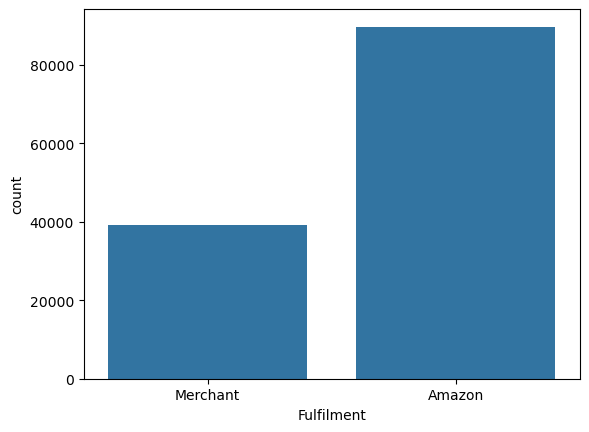

In [23]:
sns.countplot(x = "Fulfilment", data=df)
plt.show()

### Correlation Heatmap ###

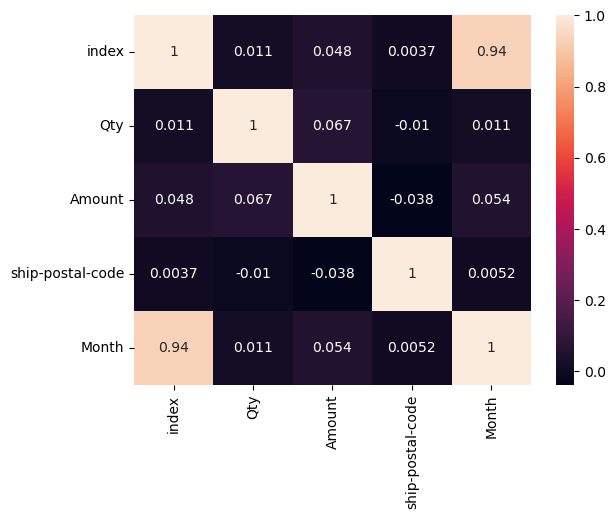

In [24]:
numeric_type = df.select_dtypes(include = "number")
sns.heatmap(numeric_type.corr(),annot=True)
plt.show()

## 2. Identify High and least performing categories ###

### Statewise Performance ###

In [25]:
statewise_high = df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False)
print(statewise_high.head(10))

ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4235215.97
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64


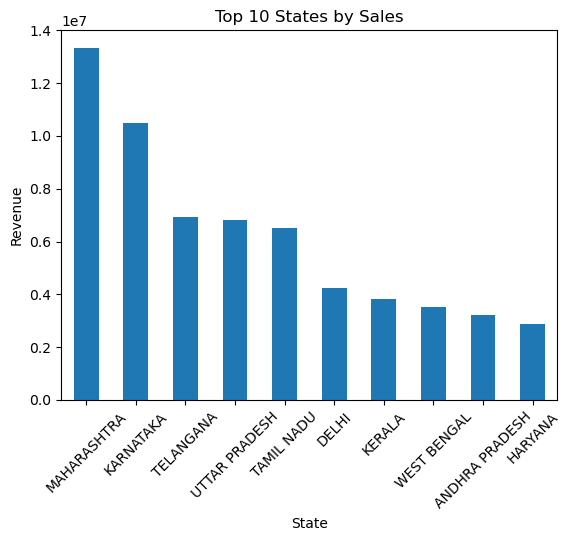

In [27]:
statewise_high.head(10).plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

### CityWise Performance ###

ship-city
BENGALURU    6849664.99
HYDERABAD    4946032.82
MUMBAI       3704461.80
NEW DELHI    3613874.78
CHENNAI      3098745.74
PUNE         2338518.18
KOLKATA      1414978.87
GURUGRAM     1221618.74
THANE        1004355.29
LUCKNOW       933926.34
Name: Amount, dtype: float64


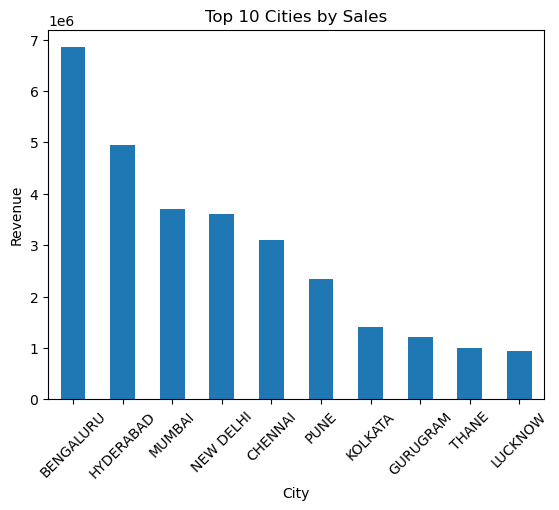

In [29]:
citywise_high = df.groupby("ship-city")["Amount"].sum().sort_values(ascending=False)
print(citywise_high.head(10))

citywise_high.head(10).plot(kind="bar")

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

### Top Performing Categories

In [31]:
category_wise = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
print(category_wise.head(10))

Category
Set              39204124.03
kurta            21299546.70
Western Dress    11216072.69
Top               5347792.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64


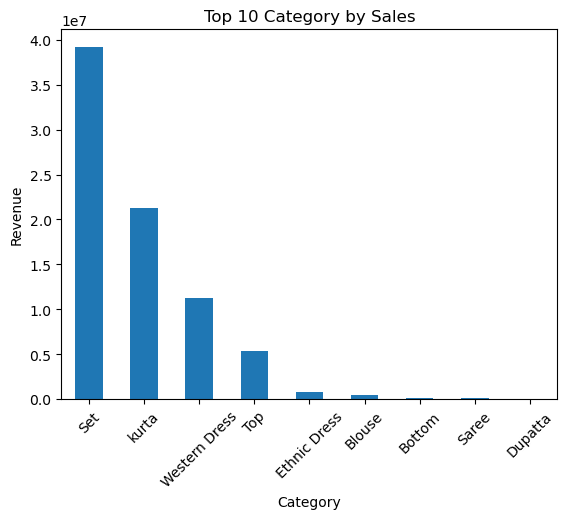

In [33]:
category_wise.head(10).plot(kind="bar")

plt.title("Top 10 Category by Sales")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

### Quantity Based ###

In [35]:
quantity_wise = df.groupby("Category")["Qty"].sum().sort_values(ascending=False)
print(quantity_wise.head(10))

Category
Set              45289
kurta            45045
Western Dress    13943
Top               9903
Ethnic Dress      1053
Blouse             863
Bottom             398
Saree              152
Dupatta              3
Name: Qty, dtype: int64


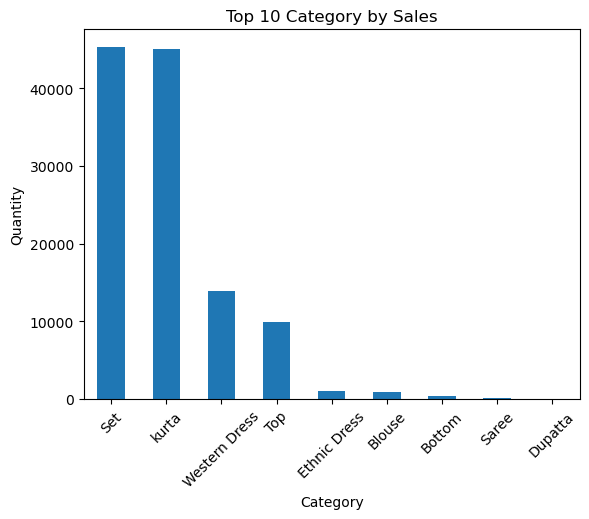

In [37]:
quantity_wise.head(10).plot(kind="bar")

plt.title("Top 10 Category by Sales")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.xticks(rotation=45)

plt.show()

### Region + Category Performance ###

In [40]:
region_category = df.pivot_table(
    values="Amount",
    index="ship-state",
    columns="Category",
    aggfunc="sum"
)

print(region_category)

Category             Blouse   Bottom  Dupatta  Ethnic Dress   Saree  \
ship-state                                                            
ANDAMAN & NICOBAR       NaN   518.00      NaN           NaN     NaN   
ANDHRA PRADESH      16982.0  5112.39      NaN      29615.52  1704.0   
APO                     NaN      NaN      NaN           NaN     NaN   
AR                      NaN      NaN      NaN           NaN     NaN   
ARUNACHAL PRADESH       NaN   518.00      NaN        699.00     NaN   
...                     ...      ...      ...           ...     ...   
goa                     NaN      NaN      NaN           NaN     NaN   
orissa                  NaN      NaN      NaN           NaN     NaN   
punjab                  NaN      NaN      NaN           NaN     NaN   
rajasthan               NaN      NaN      NaN        845.00     NaN   
rajsthan                NaN      NaN      NaN           NaN     NaN   

Category                   Set       Top  Western Dress       kurta  
ship-s

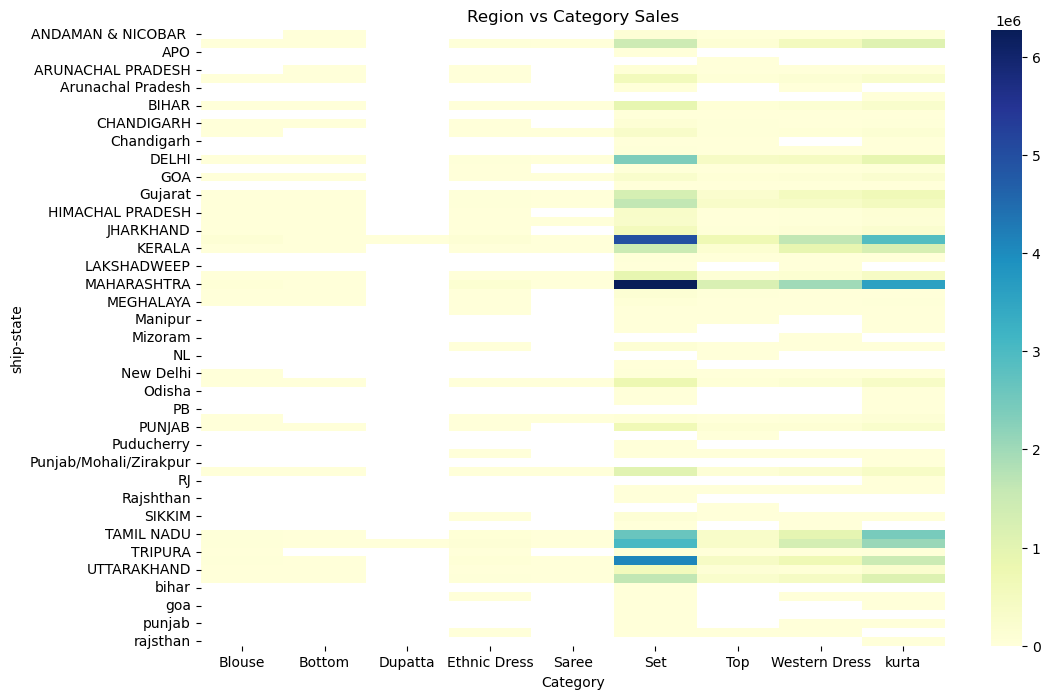

In [41]:
plt.figure(figsize=(12,8))
sns.heatmap(region_category, cmap="YlGnBu")
plt.title("Region vs Category Sales")
plt.show()

### Study session and yearly Trends ###

#### Convert Date Column and extrace date, year, month , month_name, day ####

In [44]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

### Monthly Highest Revenue ###

In [45]:
monthly_high = df.groupby("Month_Name")["Amount"].sum()
print(monthly_high)

Month_Name
April    28838708.32
June     23425809.38
March      101683.85
May      26226476.75
Name: Amount, dtype: float64


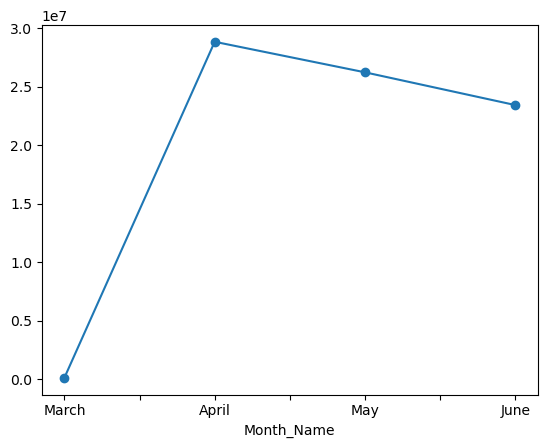

In [46]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = df.groupby("Month_Name")["Amount"].sum().reindex(month_order)

monthly_sales.plot(kind="line", marker="o")

plt.show()

### Yearly Sales ###

In [47]:
yearly_sales = df.groupby("Year")["Amount"].sum()

print(yearly_sales)

Year
2022    78592678.3
Name: Amount, dtype: float64


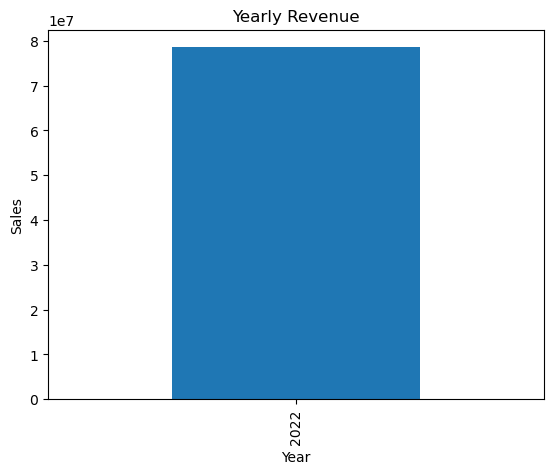

In [48]:
yearly_sales.plot(kind="bar")

plt.title("Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

### Seasonal Revenue ###

In [49]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5,6]:
        return "Summer"
    elif month in [7,8,9]:
        return "Monsoon"
    else:
        return "Festive"

df["Season"] = df["Month"].apply(get_season)

In [50]:
season_sales = df.groupby("Season")["Amount"].sum()

print(season_sales)

Season
Summer    78592678.3
Name: Amount, dtype: float64


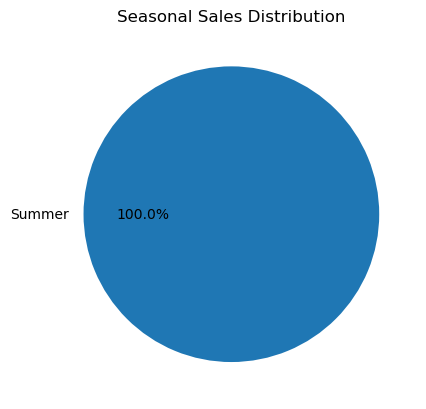

In [51]:
season_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Seasonal Sales Distribution")

plt.ylabel("")

plt.show()

### Payment behaviour ###